In [1]:
list.of.packages <- c("tidyverse","ggfixest","stargazer","data.table","ggpubr","patchwork")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : fixest


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter,

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

WB_bins_labels <- c("<=14°C","14,16]","16,18]","18,20]","20,22]","22,24]","24,26]","26,28]",">28°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

bin_ref_T <-"17,21]"
bin_ref_WB <-"16,18]"

In [3]:
varT <- "T_i30_bin"
varWB <- "WB_i130_bin"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_WB <- setNames(paste0("WBGT: ",WB_bins_labels_pretty), paste0(varWB, "::", WB_bins_labels))

dict <- c(dict_levels_T, dict_levels_WB)

# Children

In [4]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [5]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                       T_i20_bin=factor(gsub("\\(","",T_i20_bin),levels=T_bins_labels),
                       WB_i20_bin=factor(gsub("\\(","",WB_i20_bin),levels=WB_bins_labels),
                       T_i10_bin=factor(gsub("\\(","",T_i10_bin),levels=T_bins_labels),
                       WB_i10_bin=factor(gsub("\\(","",WB_i10_bin),levels=WB_bins_labels)
)

# Women

In [6]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [7]:
df_reg_women <- df_women %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                       T_i20_bin=factor(gsub("\\(","",T_i20_bin),levels=T_bins_labels),
                       WB_i20_bin=factor(gsub("\\(","",WB_i20_bin),levels=WB_bins_labels),
                       T_i10_bin=factor(gsub("\\(","",T_i10_bin),levels=T_bins_labels),
                       WB_i10_bin=factor(gsub("\\(","",WB_i10_bin),levels=WB_bins_labels)
)

# Men

In [8]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [9]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                       T_i20_bin=factor(gsub("\\(","",T_i20_bin),levels=T_bins_labels),
                       WB_i20_bin=factor(gsub("\\(","",WB_i20_bin),levels=WB_bins_labels),
                       T_i10_bin=factor(gsub("\\(","",T_i10_bin),levels=T_bins_labels),
                       WB_i10_bin=factor(gsub("\\(","",WB_i10_bin),levels=WB_bins_labels)
)

# Hemoglobin level

In [10]:
fe_reg <- function(df,Y_var,T_var,N_days,controls, FE){
    if (T_var == "T"){
        T_bin <- paste0("T_i",N_days,"_bin")
        T_ref <- bin_ref_T
    }
    else{T_bin <- paste0("WB_i",N_days,"_bin")
         T_ref <- bin_ref_WB}
    P_var <- paste0("P_tot_",N_days)
    form <- paste0(Y_var," ~ i(",T_bin,",ref='",T_ref,"') + ", P_var, controls, FE)
    #print(form)
    feols(formula(form),
          vcov = ~District_ID,                    
          df)
}

In [11]:
child_controls <-"+ Child_female + Child_birth_order + Child_alive_age_month +
                    Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                    Mother_muslim + Mother_not_hindu_nor_muslim  + 
                    Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                    Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                    Urban "

In [12]:
adults_controls <- "+ Current_age + N_year_educ + Smoker + Health_insurance + 
                      Religion_muslim + Religion_not_hindu_nor_muslim + 
                      Ethni_SC + Ethni_ST + Ethni_OBC +
                      Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                      Urban "

In [13]:
FE <- "|District_ID^Measured_month + District_ID^Measured_year"

In [14]:
reg_children_T_10 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",10,child_controls,FE)
reg_women_T_10 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",10,adults_controls,FE)
reg_men_T_10 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",10,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [15]:
reg_children_WB_10 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",10,child_controls,FE)
reg_women_WB_10 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",10,adults_controls,FE)
reg_men_WB_10 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",10,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [16]:
reg_children_T_20 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",20,child_controls,FE)
reg_women_T_20 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",20,adults_controls,FE)
reg_men_T_20 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",20,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [17]:
reg_children_WB_20 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",20,child_controls,FE)
reg_women_WB_20 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",20,adults_controls,FE)
reg_men_WB_20 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",20,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [18]:
reg_children_T_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",30,child_controls,FE)
reg_women_T_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",30,adults_controls,FE)
reg_men_T_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [19]:
reg_children_WB_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",30,child_controls,FE)
reg_women_WB_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",30,adults_controls,FE)
reg_men_WB_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



# Plot

In [20]:
theme_perso <- function(...) {
                  theme(legend.position="bottom",
                        legend.text = element_text(size = 20),
                        plot.title = element_text(size=25),
                        axis.title.x = element_text(size = 20, face = "bold"),
                        axis.text.x =  element_text(size = 20, angle=40, hjust=1),
                        axis.title.y = element_text(size = 20),
                        axis.text.y =  element_text(size = 20))
                }

In [21]:
plot_children_T <- ggiplot(list('10 days' = reg_children_T_10,
                             '20 days' = reg_children_T_20,
                             '30 days' = reg_children_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_children_WB <- ggiplot(list('10 days' = reg_children_WB_10,
                                 '20 days' = reg_children_WB_20,
                                 '30 days' = reg_children_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_children <- annotate_figure(ggarrange(plot_children_T,plot_children_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Children", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [22]:
plot_women_T <- ggiplot(list('10 days' = reg_women_T_10,
                             '20 days' = reg_women_T_20,
                             '30 days' = reg_women_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_women_WB <- ggiplot(list('10 days' = reg_women_WB_10,
                              '20 days' = reg_women_WB_20,
                              '30 days' = reg_women_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_women <- annotate_figure(ggarrange(plot_women_T,plot_women_WB,
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Women", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [24]:
plot_men_T <- ggiplot(list('10 days' = reg_men_T_10,
                           '20 days' = reg_men_T_20,
                           '30 days' = reg_men_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_men_WB <- ggiplot(list('10 days' = reg_men_WB_10,
                            '20 days' = reg_men_WB_20,
                            '30 days' = reg_men_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_men <- annotate_figure(ggarrange(plot_men_T, plot_men_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Men", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


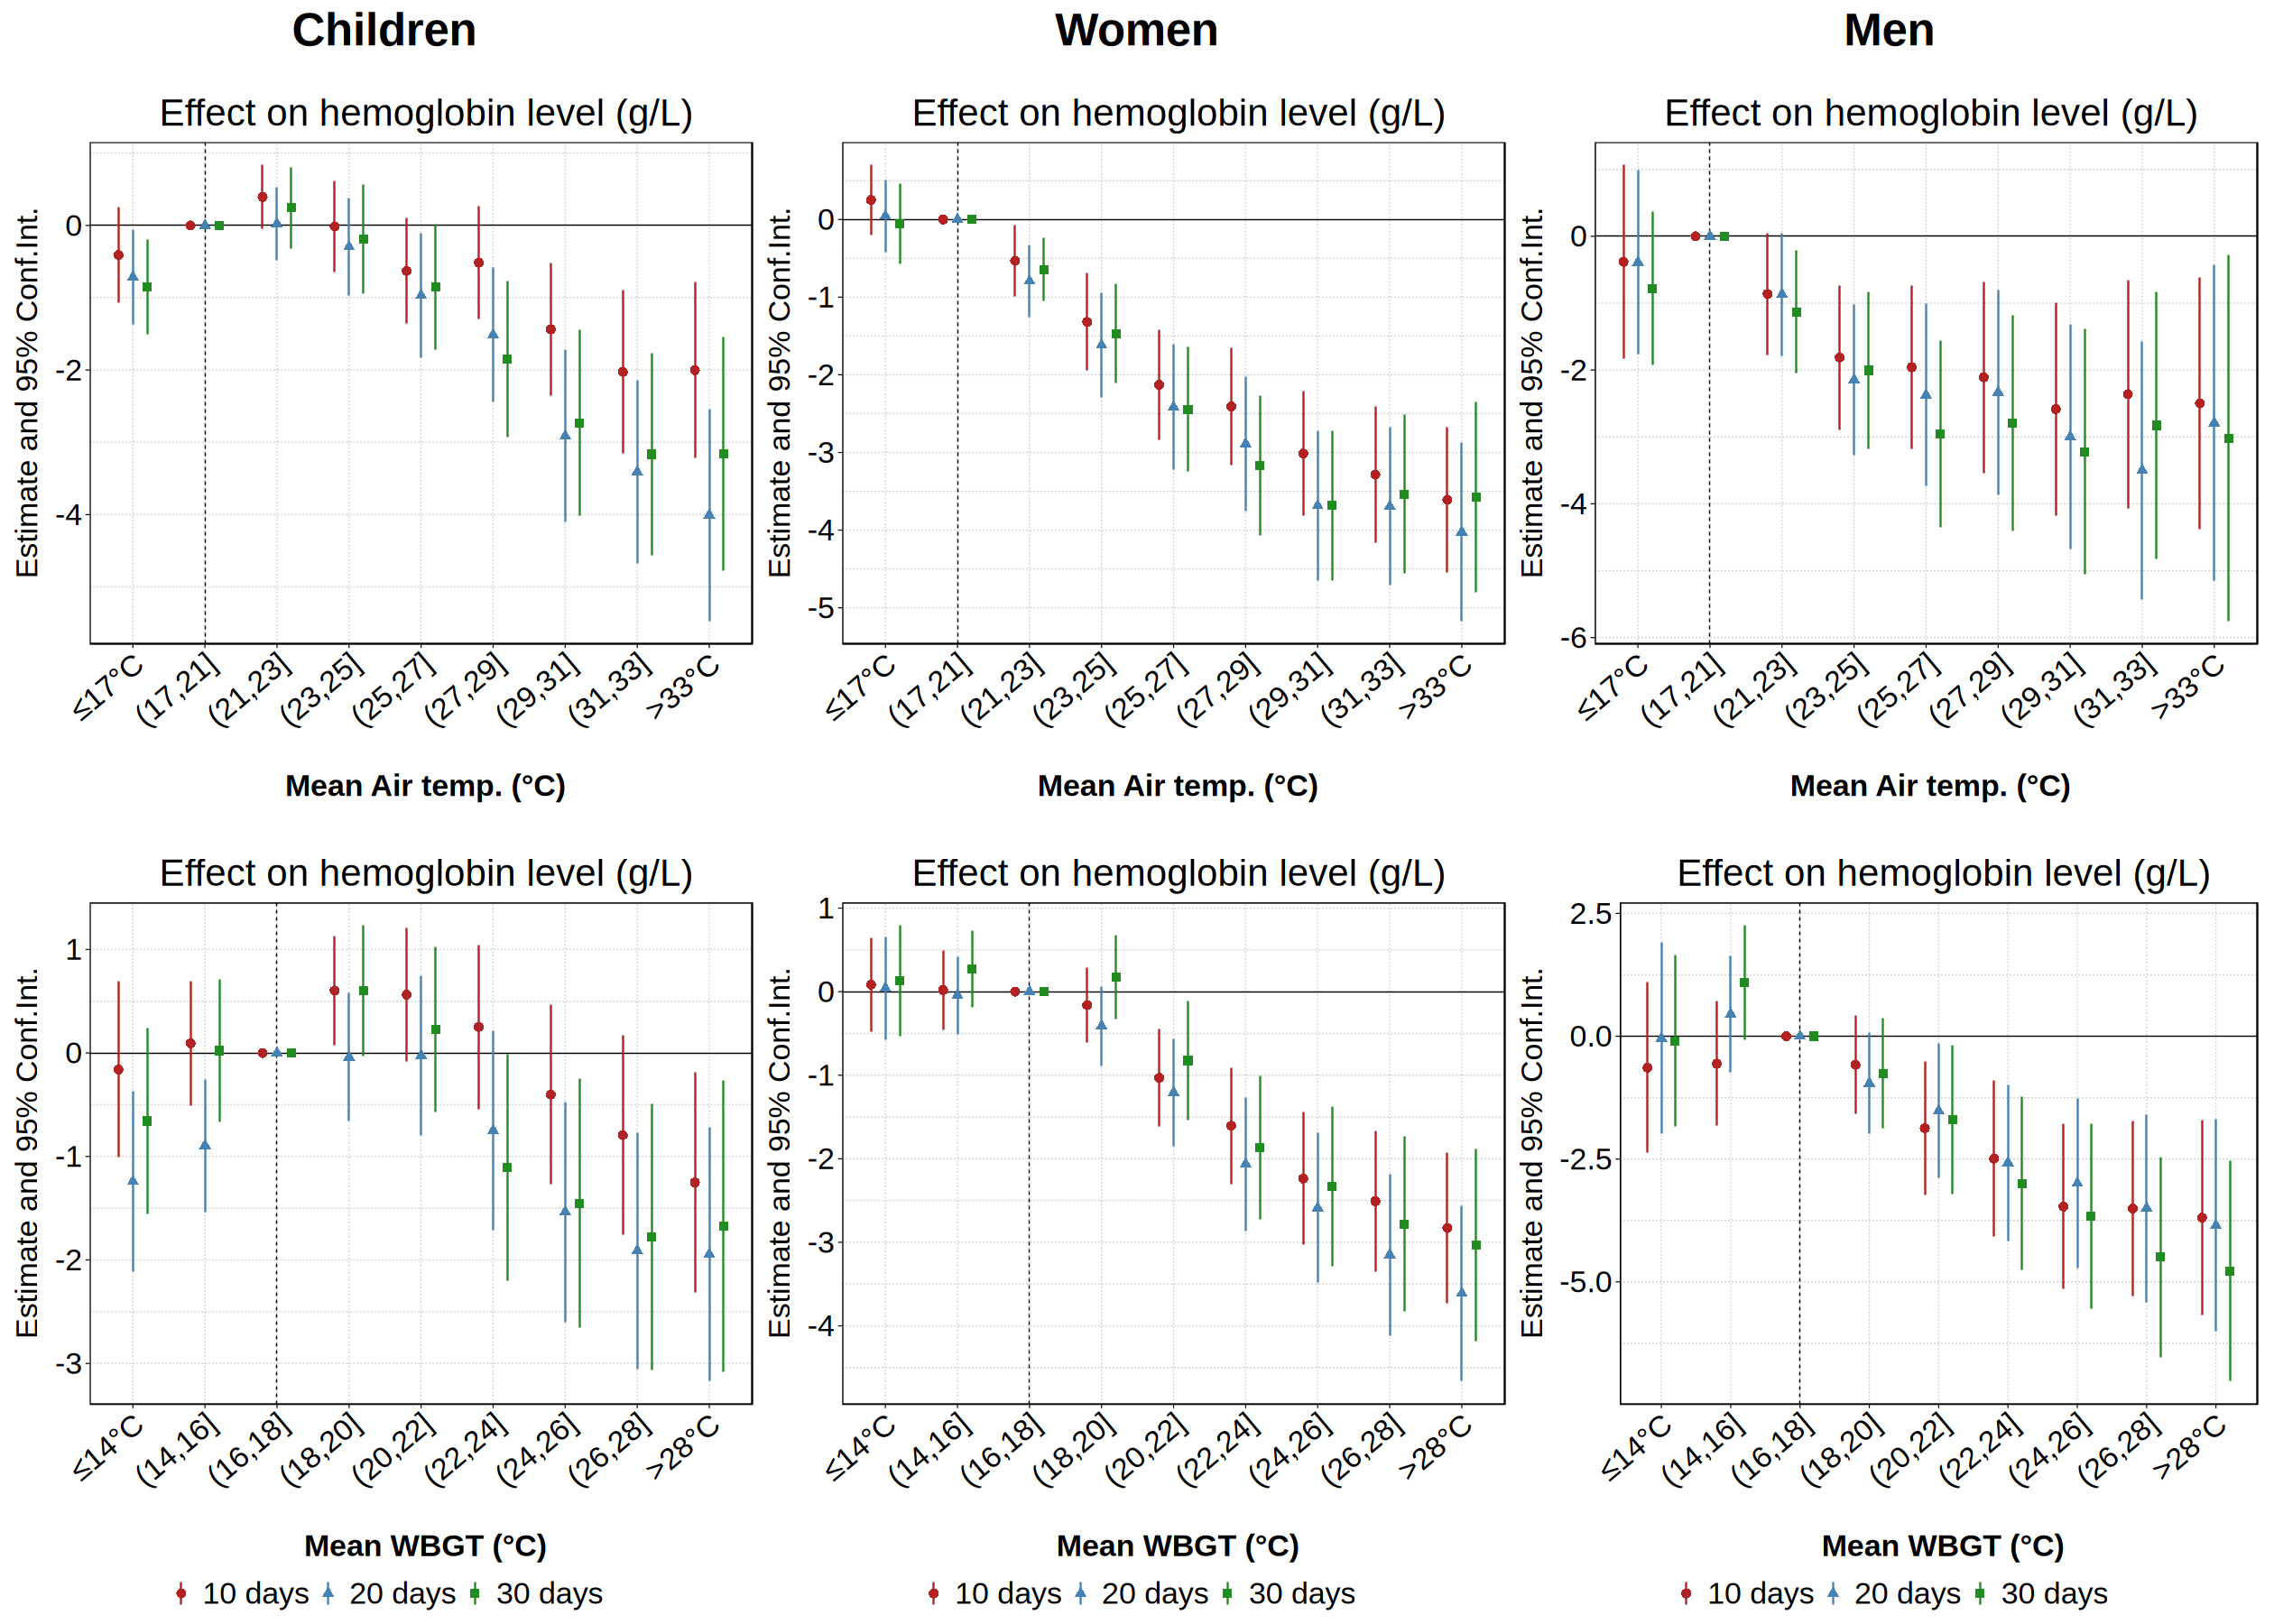

In [25]:
options(repr.plot.width=21, repr.plot.height=15, scipen=9999)

plot_all <- plot_children + plot_women + plot_men +  plot_layout(ncol=3)
plot_all

In [26]:
ggsave("./3_output/img/comp_estimates_mean.png", width=24, height=15, plot_all, device="png")